In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
from torch.nn import LayerNorm

In [2]:
!pip install thop
!pip install tdqm

  Preparing metadata (setup.py) ... done
  Created wheel for tdqm: filename=tdqm-0.0.1-py3-none-any.whl size=1322 sha256=75c4f6ec3391eb41d736993add195dacefd26168dbe68a640c3f497dc7bfe3b2
  Stored in directory: /root/.cache/pip/wheels/af/02/71/aae0f7ee738abf19498353918ddae0f90a0d6ceb337b0bbc91
Successfully built tdqm


# Part 1: Attention and Encoder-Decoder Models

In this section, you'll implement two forms of attention and use them in an encoder-decoder style transformer. You'll then compare performance based on changing dataset size and hidden dimension.

## Step 1: Scaled Dot Product Attention
Implement both the base `scaled_dot_attention` method as well as the `forward` method for the `Attention` module.

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:


def scaled_dot_attention(q, k, v, mask=0):
  """Computes scaled dot product attention with an optional mask.
    q : shape ( batch, k, hidden_size)
    k : shape ( batch, seq_len, hidden_size)
    v : shape ( batch, seq_len, hidden_size)
    mask: optional. shape (k, seq_len)

  returns:
      context   : shape (batch, k, hidden_size)
      attention : shape (batch, k, seq_len)
  """

  # ------------
  # FILL THIS IN
  # ------------
  _, _, hidden_size = q.shape
  k_t = k.transpose(1, 2)
  unnorm_attn = torch.bmm(q, k_t)
  masked_unnorm_attn = unnorm_attn + mask
  attention = nn.Softmax(dim=2)(masked_unnorm_attn / hidden_size**0.5)
  context = torch.bmm(attention, v)
  return context, attention

In [5]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.hidden_size = hidden_size

    def forward(self, x, annots):
        #   x         : shape ( batch, k, hidden_size)
        #   annots    : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # Pay attention to which inputs you use for the queries, keys, and values.
        # ------------
        q = self.Q(x)
        k = self.K(annots)
        v = self.V(annots)
        return scaled_dot_attention(q, k, v)

## Step 2: Causal Scaled Dot Product Attention
Using your `scaled_dot_attention` method, implement the `forward` method for the `CausalAttention` module.


In [6]:
class CausalAttention(Attention):
    def __init__(self, hidden_size):
        super().__init__(hidden_size)

    def forward(self, x):
        #   x : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # This should be very similar to your other attention implementation,
        # with the exception that you only have one set of outputs and you
        # must construct a causal attention mask.
        # ------------
        _, seq_len, _ = x.shape
        q = self.Q(x)
        k = self.K(x)
        v = self.V(x)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf')).masked_fill(mask == 0, 0.0).to(device)
        return scaled_dot_attention(q, k, v, mask)

#### Simple test cases
##### Passing this DOES NOT mean your implementation is correct. But, if this fails, then you definitely did something wrong

In [7]:
cros_attn = Attention(32).to(device)
caus_attn = CausalAttention(32).to(device)
caus_attn.Q = cros_attn.Q
caus_attn.K = cros_attn.K
caus_attn.V = cros_attn.V

inp = torch.randn(4, 8, 32).to(device)
inp2 = torch.randn(4, 16, 32).to(device)

print("Checking consistent shape")
assert cros_attn(inp, inp2)[0].shape == inp.shape
assert caus_attn(inp)[0].shape == inp.shape
assert cros_attn(inp, inp2)[1].shape == (4, 8, 16)
assert caus_attn(inp)[1].shape == (4, 8, 8)

print("Checking attention mask")
assert torch.all(caus_attn(inp)[0][:, -1] == cros_attn(inp, inp)[0][:, -1])

print("Passed")

Checking consistent shape
Checking attention mask
Passed


#### Read through the following code. Make sure you understand what is going on.
This code sets up the encoder-decoder architecture. It requires no additional code.

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, hidden_size, max_len = 1000):
        super().__init__()

        pos = torch.arange(max_len).float().unsqueeze(1)   # [max_len, 1]
        dim = torch.arange(hidden_size // 2).float().unsqueeze(0) # [1, hidden_size // 2]

        div_term = torch.exp(-math.log(10000.0) * (2 * dim) / hidden_size)
        angle = pos * div_term

        pe = torch.zeros(max_len, hidden_size)
        pe[:, 0::2] = torch.sin(angle)
        pe[:, 1::2] = torch.cos(angle)

        self.register_buffer("pe", pe)

    def forward(self, idx):
        return self.pe[idx]

In [9]:
class MLP(nn.Module):

    def __init__(self, hidden_size):
        super().__init__()
        self.layer1  = nn.Linear(hidden_size, hidden_size, bias=False)
        self.layer2  = nn.Linear(hidden_size, hidden_size, bias=False)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

class EncoderBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = Attention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x):
        context, attention = self.attn(self.norm1(x), self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention

class DecoderBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.cros_attn = Attention(hidden_size)
        self.self_attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x, annotation):
        context, self_attn = self.self_attn(self.norm1(x))
        x = x + context
        context, cros_attn = self.cros_attn(self.norm2(x), annotation)
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, self_attn, cros_attn

In [10]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.encoder_blocks = nn.ModuleList(
            [EncoderBlock(hidden_size) for i in range(num_layers)]
        )
        self.decoder_blocks = nn.ModuleList(
            [DecoderBlock(hidden_size) for i in range(num_layers)]
        )

        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

        self.apply(self._init_weights) # initialize the weights to a small number

    def forward(self, inputs, annots):

        pos_x = torch.arange(0, inputs.shape[-1], device=inputs.device).long() # creates tensor([0, 1, 2, 3, ...])
        pos_y = torch.arange(0, annots.shape[-1], device=inputs.device).long() # creates tensor([0, 1, 2, 3, ...])

        x = self.tok_emb(inputs) + self.pos_emb(pos_x)
        y = self.tok_emb(annots) + self.pos_emb(pos_y)

        self_attn = []
        cros_attn = []

        for encode in self.encoder_blocks:
            y, _ = encode(y)

        for decode in self.decoder_blocks:
            x, s, c = decode(x, y)
            cros_attn.append(c)
            self_attn.append(s)

        return self.head(x), {'self_attn': self_attn, 'cros_attn': cros_attn}

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

## Step 3: Training the model

You'll now train a set of example models. This section requires no additional code from you, with the exception of setting the datapath. However, **you are required to analyze and include some of its output**.

In [11]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.insert(0, '/content/drive/MyDrive/NNDL_hw2/')


Mounted at /content/drive/


In [12]:
import os
os.listdir('/content/drive/MyDrive/NNDL_hw2/')

['pig_latin_small.txt',
 'pig_latin_large.txt',
 '__pycache__',
 'hw_utils.py',
 'hw_dataset.py',
 'hw_trainer.py']

In [13]:
script_path = '/content/drive/MyDrive/NNDL_hw2/pig_latin_small.txt'
if os.path.exists(script_path):
    print(f"File found at {script_path}")
else:
    print(f"File not found at {script_path}")

File found at /content/drive/MyDrive/NNDL_hw2/pig_latin_small.txt


In [14]:
from hw_dataset import EncoderDecoderDataset, DecoderDataset
from hw_utils import save_loss_comparison_by_dataset, save_loss_comparison_by_hidden
from torch.utils.data import DataLoader
from hw_trainer import train
import torch.optim as optim

data_path = '/content/drive/MyDrive/NNDL_hw2/' # Change data_path to where the data is stored

encdec_ds_small = EncoderDecoderDataset(data_path, 'pig_latin_small')
encdec_ds_large = EncoderDecoderDataset(data_path, 'pig_latin_large')


In [15]:
print("device: ", device)
print("Dataset sample:")
print("Input:", encdec_ds_small.to_token(encdec_ds_small[0][0].tolist()))
print("Annotation:", encdec_ds_small.to_token(encdec_ds_small[0][1].tolist()))
print("Target:", encdec_ds_small.to_token(encdec_ds_small[0][2].tolist()))

device:  cuda
Dataset sample:
Input: <SOS>ointurejay
Annotation: jointure
Target: ointurejay<EOS>


In [16]:
model = TransformerEncoderDecoder(
    vocab_size = len(encdec_ds_small.idx_to_token),
    hidden_size = 16,
    num_layers = 4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=encdec_ds_small,
    num_epochs=25,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size = 32
)

Epoch 1 | Train loss: 2.633033 | Val loss 2.295843
Epoch 2 | Train loss: 2.116268 | Val loss 1.929454
Epoch 3 | Train loss: 1.729609 | Val loss 1.577802
Epoch 4 | Train loss: 1.247981 | Val loss 1.092966
Epoch 5 | Train loss: 0.861785 | Val loss 0.709078
Epoch 6 | Train loss: 0.618398 | Val loss 0.549792
Epoch 7 | Train loss: 0.465059 | Val loss 0.427674
Epoch 8 | Train loss: 0.333337 | Val loss 0.309601
Epoch 9 | Train loss: 0.263652 | Val loss 0.273112
Epoch 10 | Train loss: 0.231912 | Val loss 0.239891
Epoch 11 | Train loss: 0.176023 | Val loss 0.223645
Epoch 12 | Train loss: 0.159101 | Val loss 0.206219
Epoch 13 | Train loss: 0.153471 | Val loss 0.180688
Epoch 14 | Train loss: 0.130750 | Val loss 0.177116
Epoch 15 | Train loss: 0.118399 | Val loss 0.195135
Epoch 16 | Train loss: 0.108003 | Val loss 0.162593
Epoch 17 | Train loss: 0.088285 | Val loss 0.140666
Epoch 18 | Train loss: 0.085042 | Val loss 0.126462
Epoch 19 | Train loss: 0.072131 | Val loss 0.108577
Epoch 20 | Train loss

In [17]:
def encdec_generate(input, model, dataset, max_len=20):
    gen_string = ""
    idx = torch.tensor([[dataset.start_idx]]).to(device)
    annots = torch.tensor([dataset.to_idx(input) + [dataset.end_idx]*(max(0, 12-len(input)))]).to(device)
    #pad the input string with <EOS> since the collate_fn had to pad the stirngs

    for i in range(max_len):
        logits = model(idx, annots)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string

def encdec_translate(sentence, model, dataset):
    words = sentence.split()
    return " ".join([encdec_generate(w, model, dataset) for w in words])

In [18]:
encdec_translate('the', model, encdec_ds_small)

'ethay'

In [19]:
encdec_translate("the air conditioning is working", model, encdec_ds_small)

'ethay airway onditioningcay isway orkingway'

In [20]:
encdec_translate("testing some random words", model, encdec_ds_small)

'estingtay omesay andomray ordsway'


Training model: hidden_size=16, dataset=small
Epoch 1 | Train loss: 2.627159 | Val loss 2.469531
Epoch 2 | Train loss: 2.173785 | Val loss 1.987291
Epoch 3 | Train loss: 1.923064 | Val loss 1.800075
Epoch 4 | Train loss: 1.649164 | Val loss 1.546942
Epoch 5 | Train loss: 1.300516 | Val loss 1.132861
Epoch 6 | Train loss: 0.897618 | Val loss 0.771913
Epoch 7 | Train loss: 0.619260 | Val loss 0.536110
Epoch 8 | Train loss: 0.415532 | Val loss 0.401012
Epoch 9 | Train loss: 0.311511 | Val loss 0.348926
Epoch 10 | Train loss: 0.251104 | Val loss 0.261009
Epoch 11 | Train loss: 0.204519 | Val loss 0.253719
Epoch 12 | Train loss: 0.179698 | Val loss 0.224429
Epoch 13 | Train loss: 0.142496 | Val loss 0.180925
Epoch 14 | Train loss: 0.121563 | Val loss 0.156468
Epoch 15 | Train loss: 0.103318 | Val loss 0.143149
Epoch 16 | Train loss: 0.101606 | Val loss 0.161816
Epoch 17 | Train loss: 0.088924 | Val loss 0.139006
Epoch 18 | Train loss: 0.081149 | Val loss 0.108428
Epoch 19 | Train loss: 0.0

<Figure size 640x480 with 0 Axes>

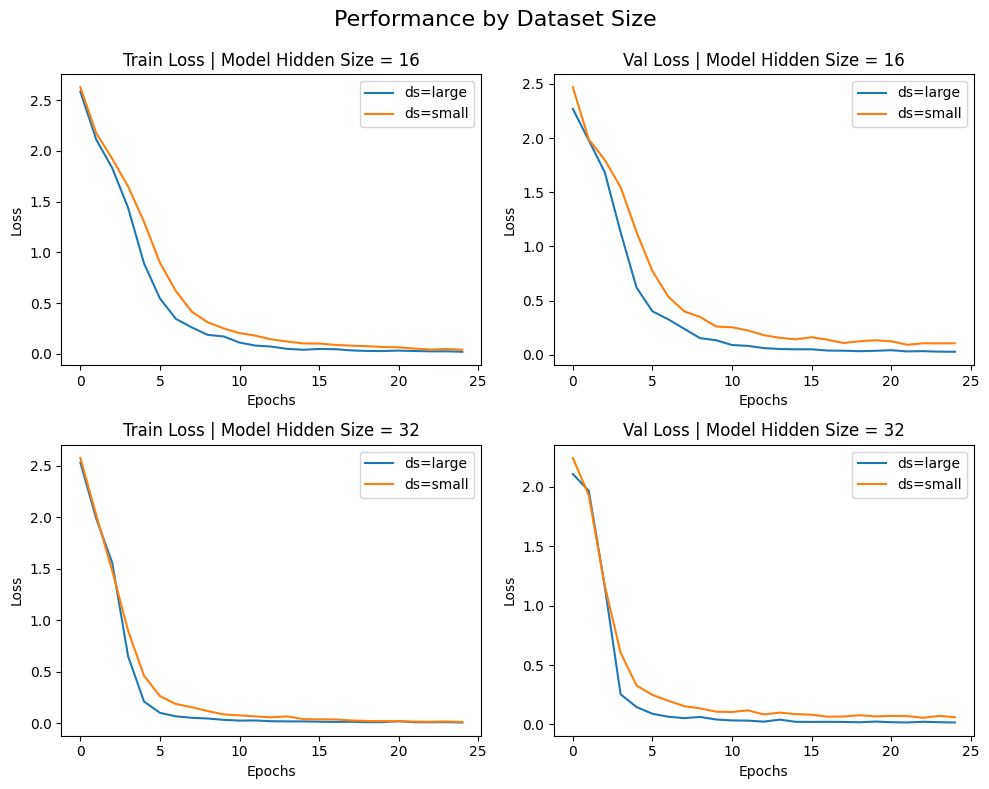

<Figure size 640x480 with 0 Axes>

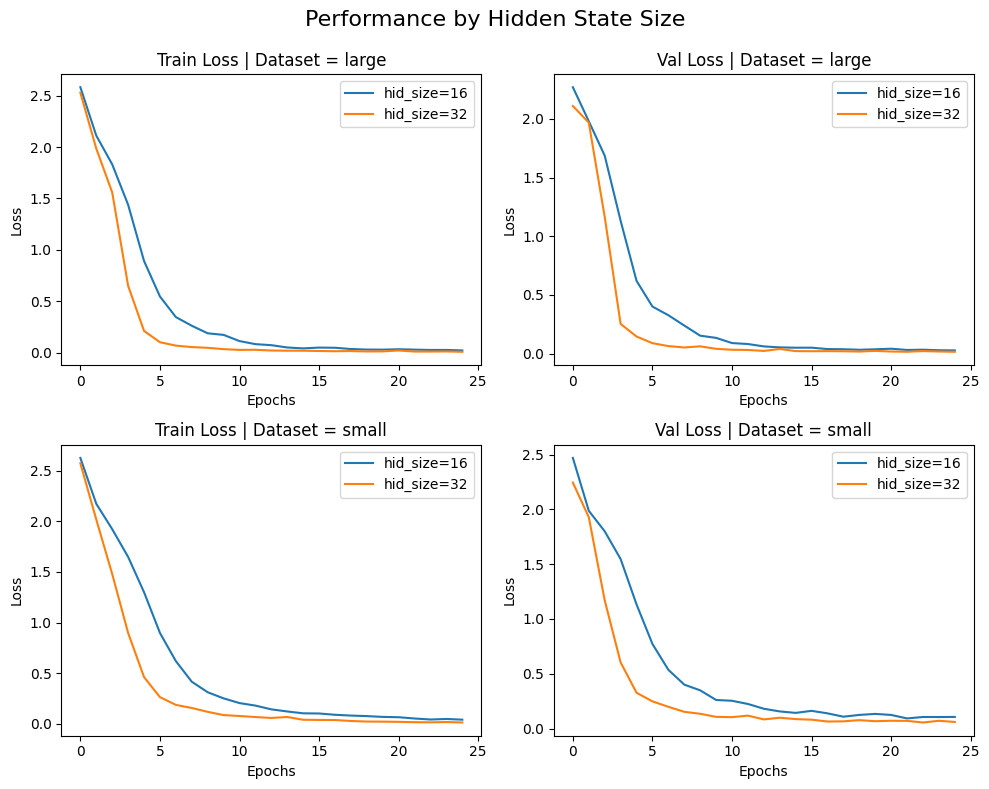

In [21]:
configs = [
    (16, 'small', encdec_ds_small),
    (16, 'large', encdec_ds_large),
    (32, 'small', encdec_ds_small),
    (32, 'large', encdec_ds_large)
]

all_results = {}

for hidden_size, dataset_name, dataset in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, dataset={dataset_name}")

    model = TransformerEncoderDecoder(
        vocab_size=len(dataset.idx_to_token),
        hidden_size=hidden_size,
        num_layers=4
    )
    optimizer = optim.AdamW(model.parameters(), lr=1e-2)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = dataset,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = 32 if dataset_name == "small" else 256
    )
    all_results[(hidden_size, dataset_name)] = results

save_loss_comparison_by_dataset(all_results)
save_loss_comparison_by_hidden(all_results)

# Part 2: Decoder-only Transformers and Multi-Head Attention

In this section, you'll train transformers that only use a decoder instead of a dual encoder-decoder architecture. You'll also implement and experiment with multi-head attention. Finally, you'll compare increasing parameter count with multi-head attention vs. increasing the parameter count with a larger hidden dimensionality.

## Step 1: Implement the Decoder-Only Forward Method

In [22]:
class DecoderOnlyBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x):
        context, attention = self.attn(self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention

class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.blocks = nn.ModuleList(
            [DecoderOnlyBlock(hidden_size) for i in range(num_layers)]
        )
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

    def forward(self, inputs):
        """Forward pass of the Transformer decoder.

        Arguments:
            inputs: Input token indexes across a batch for all the time step. (batch_size x decoder_seq_len)
        Returns:
            output: Un-normalized scores for each token in the vocabulary, across a batch for all the decoding time steps. (batch_size x decoder_seq_len x vocab_size)
            attentions: The stacked attention weights applied to the encoder annotations (batch_size x encoder_seq_len x decoder_seq_len) ? (batch_size x decoder_seq_len x num_layers)
        """
        # ------------
        # FILL THIS IN
        # ------------
        pos = torch.arange(0, inputs.shape[-1], device=inputs.device).long()
        x = self.tok_emb(inputs) + self.pos_emb(pos)
        self_attn = []

        for block in self.blocks:
            x, s = block(x)
            self_attn.append(s)

        unormalized_scores = self.head(x)
        # unormalized_scores = nn.Softmax(dim=2)(x)

        return unormalized_scores, {'self_attn': self_attn}

In [23]:
decoder_ds_small = DecoderDataset(data_path, 'pig_latin_small')
decoder_ds_large = DecoderDataset(data_path, 'pig_latin_large')

In [24]:
print("Dataset sample:")
print("Input:", decoder_ds_small.to_token(decoder_ds_small[0][0].tolist()))
print("Target:", decoder_ds_small.to_token(decoder_ds_small[0][1].tolist()))

Dataset sample:
Input: <SOS>jointure<EOP>ointurejay
Target: jointure<EOP>ointurejay<EOS>


## Step 2: Format for decoder-only generation.

Implement the missing line in `decoder_generate` to create an input string that looks like:

```
<SOS> input sequence <EOP>
```
You should use the `dataset.start_idx`, `dataset.eop_idx` attributes and the `dataset.to_idx()` method.

In [25]:
def decoder_generate(input, model, dataset, max_len=20):
    gen_string = ""
    idx = dataset.to_idx(input)
    idx.insert(0, dataset.start_idx)
    idx.append(dataset.eop_idx)
    idx = torch.tensor([idx]).to(device)

    for i in range(max_len):
        logits = model(idx)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string

def decoder_translate(sentence, model, dataset):
    words = sentence.split()
    return " ".join([decoder_generate(w, model, dataset) for w in words])

## Step 3: Train the model

We'll now train a decoder only model and test it out on an example. Use the output of this to guide your answer for question 3.

In [41]:


model = DecoderTransformer(
    vocab_size = len(decoder_ds_small.idx_to_token),
    hidden_size = 16,
    num_layers = 4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model = model,
    dataset = decoder_ds_small,
    num_epochs = 25,
    optimizer = optimizer,
    scheduler = scheduler,
    device = device,
    batch_size = 32
)

Epoch 1 | Train loss: 2.959441 | Val loss 1.862668
Epoch 2 | Train loss: 1.696339 | Val loss 1.547879
Epoch 3 | Train loss: 1.444591 | Val loss 1.339576
Epoch 4 | Train loss: 1.143674 | Val loss 0.998153
Epoch 5 | Train loss: 0.805221 | Val loss 0.654383
Epoch 6 | Train loss: 0.601788 | Val loss 0.447158
Epoch 7 | Train loss: 0.457014 | Val loss 0.413508
Epoch 8 | Train loss: 0.347478 | Val loss 0.326237
Epoch 9 | Train loss: 0.285226 | Val loss 0.365019
Epoch 10 | Train loss: 0.270870 | Val loss 0.335094
Epoch 11 | Train loss: 0.229512 | Val loss 0.312761
Epoch 12 | Train loss: 0.229761 | Val loss 0.196539
Epoch 13 | Train loss: 0.175130 | Val loss 0.412157
Epoch 14 | Train loss: 0.184320 | Val loss 0.189294
Epoch 15 | Train loss: 0.163394 | Val loss 0.242584
Epoch 16 | Train loss: 0.144838 | Val loss 0.200012
Epoch 17 | Train loss: 0.139758 | Val loss 0.183968
Epoch 18 | Train loss: 0.127602 | Val loss 0.160130
Epoch 19 | Train loss: 0.131091 | Val loss 0.177926
Epoch 20 | Train loss

In [42]:
print(decoder_translate("the air conditioning is working", model, decoder_ds_small))
print(decoder_translate('the', model, encdec_ds_small))
print(decoder_translate("testing some random words", model, encdec_ds_small))

ethay airway onditionsscay isway orkingway
ethay
estingtay omesay andomray ordsway


## Step 4: Implement Multi-Head Attention

In this next step, you'll implement multi-head attention. In this setting, we'll have the dimensionality for each of the heads be (total hidden dimensionality)/(number of heads). We'll use a projection head to combine the outputs of these different attention heads after concatenating their outputs together (which can also be achieved using tensor reshaping).

In [28]:


# TO DO:

def multihead_scaled_dot_attention(q, k, v, mask=0):
    """ Compute multi-head dot product attention.
      q : shape (batch, num_heads, k, hidden_size)
      k : shape (batch, num_heads, seq_len, hidden_size)
      v : shape (batch, num_heads, seq_len, hidden_size)

    returns:
        context   : shape (batch, num_heads, k, hidden_size)
        attention : shape (batch, num_heads, k, seq_len)
    """
    # Hint: if you implemented scaled_dot_attention well, the code for this should be the exact same.

    # ------------
    # FILL THIS IN
    # ------------
    hidden_size = q.shape[-1]
    unnorm_attn = torch.matmul(q, k.transpose(2, 3))
    # print(f"attn shape {unnorm_attn.shape} mask {mask.shape}")
    masked_unnorm_attn = unnorm_attn + mask
    attention = nn.Softmax(dim=-1)(masked_unnorm_attn / hidden_size ** 0.5)
    context = torch.matmul(attention, v)
    return context, attention

In [29]:
class MultiheadCausalAttention(Attention):
    def __init__(self, hidden_size, num_heads):
        super().__init__(hidden_size)
        # self.Q, self.K, self.V already defined as nn.Linear(hidden_size, hidden_size)
        self.num_heads = num_heads
        # ------------
        # FILL THIS IN
        # ------------
        if self.num_heads > 1:
          self.proj = nn.Linear( hidden_size, hidden_size, bias=False)


    def forward(self, x):

        """ Compute causal multi-head dot product attention from an input sequence.
          x : shape ( batch, seq_len, hidden_size)
          k : shape (batch, num_heads, seq_len, hidden_size)
          v : shape (batch, num_heads, seq_len, hidden_size)

        returns:
            context : shape ( batch, seq_len, hidden_size)
            attention : shape (batch, num_heads, k, seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # unnorm_attn =
        # masked_unnorm_attn =
        # attention =
        # context =

        B, T, C = x.size()
        q = self.Q(x).view( B, T, self.num_heads, -1).transpose(1, 2)
        k = self.K(x).view( B, T, self.num_heads, -1).transpose(1, 2)
        v = self.V(x).view( B, T, self.num_heads, -1).transpose(1, 2)

        mask = torch.triu(torch.ones(T, T), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf')).masked_fill(mask == 0, 0.0).to(device)
        mask = mask[None, None, :, :]

        context, attention = multihead_scaled_dot_attention(q, k, v, mask)

        # Hint: you may find the .transpose(), .contiguous(), and .view()
        # methods helpful for creating the reshaped context.

        reshaped_context = context.transpose(1, 2).contiguous().view( B, T, -1)

        # Only perform a projection if the number of heads is more than 1.
        if self.num_heads > 1:
          return self.proj(reshaped_context), attention
        else:
          return reshaped_context, attention

In [30]:
class MultiheadDecoderBlock(DecoderOnlyBlock):
    def __init__(self, hidden_size, num_heads):
        super().__init__(hidden_size)
        self.attn = MultiheadCausalAttention(hidden_size, num_heads)


class MultiheadDecoderTransformer(DecoderTransformer):
    def __init__(self, vocab_size, hidden_size, num_layers, num_heads):
        super().__init__(vocab_size, hidden_size, num_layers)
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.blocks = nn.ModuleList(
            [MultiheadDecoderBlock(hidden_size, num_heads) for i in range(num_layers)]
        )

## Step 5: Compare Parameter Usage Methods

Here, you'll train 5 models with varying numbers of attention heads and hidden dimensionalities. You'll compare their parameter efficiency. Start by implementing the `calc_parameters_decoder` method, and then run the code to train the models.

In [31]:
def calc_parameters_decoder(model):
  # ------------
  # FILL THIS IN
  # ------------
  params = model.vocab_size * model.hidden_size # embedding
  params +=  model.num_layers * 3 * model.hidden_size ** 2 # QKV linear projections
  if model.num_heads > 1:
    params += model.hidden_size ** 2 * model.num_layers # attention linear projection
  params += 2*model.hidden_size**2 * model.num_layers # MLP linear
  params += model.hidden_size * 2 * 2 * model.num_layers # layer norms Hint: LayerNorm(x) uses x parameters

  # Hint: Read the code carefully:
  params += model.hidden_size * model.vocab_size # head
  params_correct = sum(p.numel() for p in model.parameters() if p.requires_grad) + model.hidden_size * model.vocab_size # We reuse the embedding weight for head weight
  assert params == params_correct

  return params



Training model: hidden_size=16, num_heads=4, num_layers=4
Epoch 1 | Train loss: 4.952487 | Val loss 2.241700
Epoch 2 | Train loss: 2.019290 | Val loss 1.890594
Epoch 3 | Train loss: 1.767369 | Val loss 1.702805
Epoch 4 | Train loss: 1.605520 | Val loss 1.572074
Epoch 5 | Train loss: 1.487657 | Val loss 1.474873
Epoch 6 | Train loss: 1.393844 | Val loss 1.390843
Epoch 7 | Train loss: 1.319559 | Val loss 1.341548
Epoch 8 | Train loss: 1.256917 | Val loss 1.294711
Epoch 9 | Train loss: 1.195307 | Val loss 1.224653
Epoch 10 | Train loss: 1.144967 | Val loss 1.198920
Epoch 11 | Train loss: 1.090549 | Val loss 1.138300
Epoch 12 | Train loss: 1.048564 | Val loss 1.106723
Epoch 13 | Train loss: 1.012170 | Val loss 1.081163
Epoch 14 | Train loss: 0.969843 | Val loss 1.046105
Epoch 15 | Train loss: 0.932219 | Val loss 0.993778
Epoch 16 | Train loss: 0.898488 | Val loss 0.967719
Epoch 17 | Train loss: 0.864790 | Val loss 0.941912
Epoch 18 | Train loss: 0.829122 | Val loss 0.895317
Epoch 19 | Tra

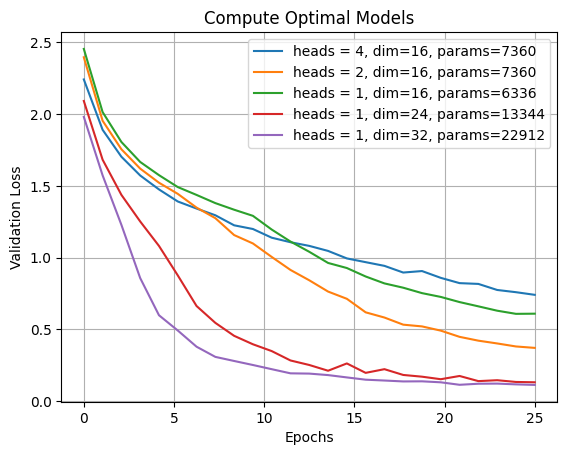

In [32]:

import matplotlib.pyplot as plt
import numpy as np
configs = [
    (16, 4, 4, 64), #(hidden_size, num_heads, num_layers, batch_size)
    (16, 2, 4, 64),
    (16, 1, 4, 64),
    (24, 1, 4, 64),
    (32, 1, 4, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}")

    model = MultiheadDecoderTransformer(
        vocab_size = len(decoder_ds_small.idx_to_token),
        hidden_size = hidden_size,
        num_layers = num_layers,
        num_heads = num_heads
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = decoder_ds_small,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = batch_size
    )

    print(decoder_translate("the air conditioning is working", model, decoder_ds_small))

    parameters = calc_parameters_decoder(model)
    x_points = np.linspace(0, len(results['val_loss']), len(results['val_loss']))
    plt.plot(
        x_points, results['val_loss'], label="heads = {}, dim={}, params={}".format(
            num_heads, hidden_size, parameters
        ))

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title('Compute Optimal Models')
plt.grid()
plt.legend()
plt.show()

In [33]:
plt.clf()

<Figure size 640x480 with 0 Axes>

# Part 3: IsoFLOP Profiling and Scaling Laws
In this final section, you'll compare different architectures based on their compute efficiency. You will also determine the optimal number of parameters and tokens for a fixed compute budget.

While this section does not require any additional code from you, **use the output of it to guide your written responses**.

In [34]:
from hw_utils import (
    plot_scaling_law,
    plot_scaling_law_poly,
    interpolate,
    plot_flops_tokens,
    plot_isoflop,
    plot_flops_params
)

import numpy as np

## Step 1: Train models, Compare FLOPS vs Validation Loss

We'll inspect the compute efficiency of different models by plotting their validation loss against the number of FLOPs used in training up to that point.

In [35]:

configs = [
    (40, 2, 4, 256), #(hidden_size, num_heads, num_layers, batch_size)
    (32, 2, 4, 128),
    (24, 2, 4, 64),
    (16, 1, 4, 64),
    (16, 1, 3, 64),
    (12, 1, 3, 64),
    (12, 1, 2, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}")

    model = MultiheadDecoderTransformer(
        vocab_size = len(decoder_ds_large.idx_to_token),
        hidden_size = hidden_size,
        num_layers = num_layers,
        num_heads = num_heads
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model = model,
        dataset = decoder_ds_large,
        num_epochs = 25,
        optimizer = optimizer,
        scheduler = scheduler,
        device = device,
        batch_size = batch_size
    )

    parameters = calc_parameters_decoder(model)
    all_results[parameters] = results



Training model: hidden_size=40, num_heads=2, num_layers=4
Epoch 1 | Train loss: 4.647412 | Val loss 1.310029
Epoch 2 | Train loss: 0.817189 | Val loss 0.410386
Epoch 3 | Train loss: 0.273787 | Val loss 0.186530
Epoch 4 | Train loss: 0.134680 | Val loss 0.140075
Epoch 5 | Train loss: 0.086045 | Val loss 0.077013
Epoch 6 | Train loss: 0.048796 | Val loss 0.054302
Epoch 7 | Train loss: 0.038497 | Val loss 0.033973
Epoch 8 | Train loss: 0.028123 | Val loss 0.032140
Epoch 9 | Train loss: 0.020528 | Val loss 0.034605
Epoch 10 | Train loss: 0.018410 | Val loss 0.028292
Epoch 11 | Train loss: 0.011634 | Val loss 0.022705
Epoch 12 | Train loss: 0.010552 | Val loss 0.017911
Epoch 13 | Train loss: 0.006111 | Val loss 0.013064
Epoch 14 | Train loss: 0.006691 | Val loss 0.016909
Epoch 15 | Train loss: 0.010981 | Val loss 0.019190
Epoch 16 | Train loss: 0.005636 | Val loss 0.012260
Epoch 17 | Train loss: 0.003799 | Val loss 0.014824
Epoch 18 | Train loss: 0.003084 | Val loss 0.012506
Epoch 19 | Tra

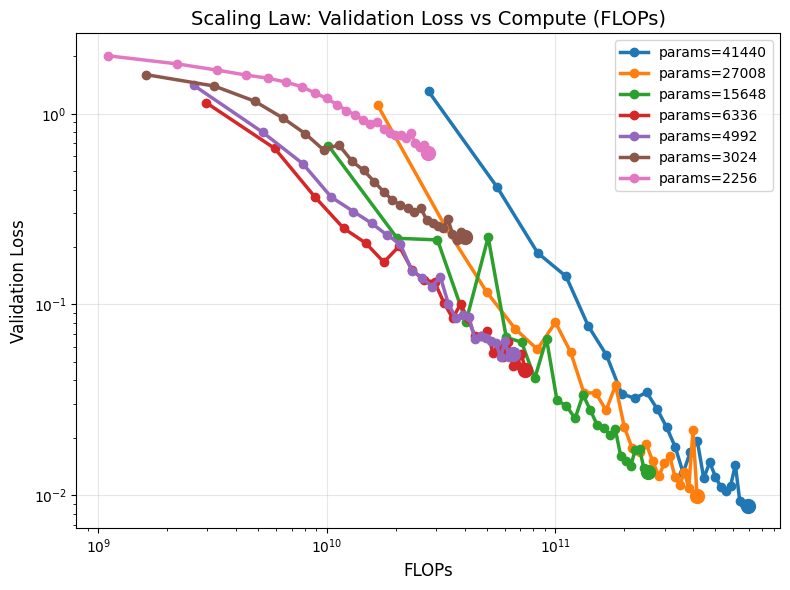

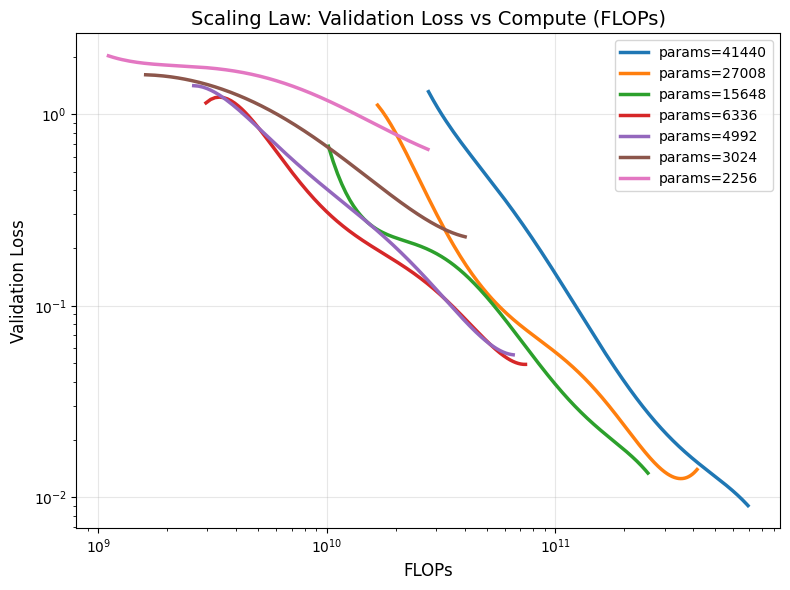

In [36]:
plot_scaling_law(all_results)

plot_scaling_law_poly(all_results)

## Step 2: Optimal Number of Parameters

Using the previously created training runs, we'll fit quadratic functions to the (parameter count, validation loss) pairs to estimate the optimal number of parameters for a given compute budget. We'll then fit a line to this set of optimal parameters to estimate the optimal number of parameters for a compute budget of 1e15.

In [37]:
def find_optim_params(params, loss):
    x = np.array(params)
    y = np.array(loss)

    p = np.polyfit(np.log10(x), y, 2)
    optimal_log_params = -(p[1]) / (2 * p[0])
    optimal_params = 10**(optimal_log_params)

    return optimal_params


target_flops = [8e9, 16e9, 32e9, 64e9, 128e9]
colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00']
params_vs_loss = []
optimal_params = []

for target in target_flops:
  parameters = []
  val_loss = []

  for params, results in all_results.items():
    loss = interpolate(results['val_loss'], results['flops'], target, deg=4)
    # interpolate returns None if target is out of range
    if loss != None:
      parameters.append(params)
      val_loss.append(loss)

  sorted_indices = torch.argsort(torch.tensor(parameters))
  parameters = torch.tensor(parameters)[sorted_indices]
  val_loss = torch.tensor(val_loss)[sorted_indices]

  optimal_params.append(find_optim_params(parameters, val_loss))
  params_vs_loss.append((parameters.tolist(), val_loss.tolist()))


8.00 GFlops: Optimal params = 5,396
16.00 GFlops: Optimal params = 7,185
32.00 GFlops: Optimal params = 7,059
64.00 GFlops: Optimal params = 9,904
128.00 GFlops: Optimal params = 23,714


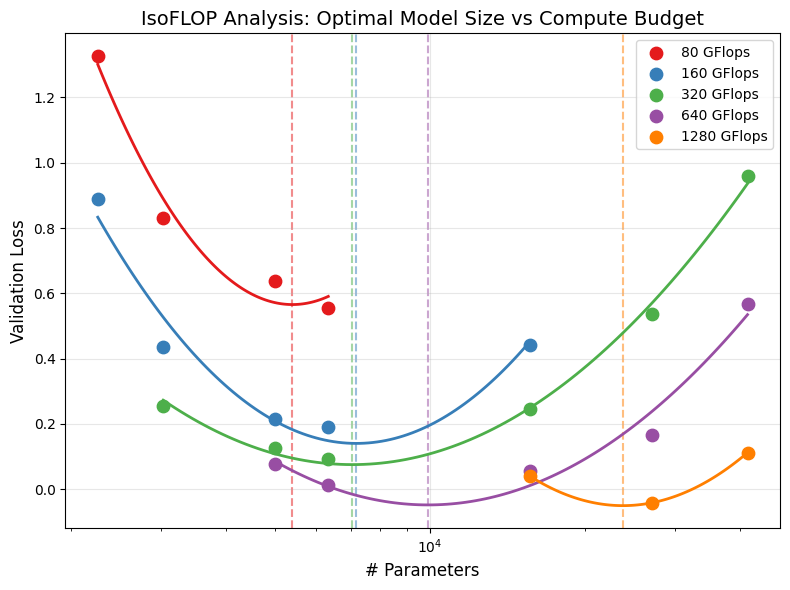

In [38]:
plot_isoflop(target_flops, colors, params_vs_loss, optimal_params)

y = 0.4734763947670522x + -1.0123419693989038


/content/drive/MyDrive/NNDL_hw2/hw_utils.py:246: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = "lower left")


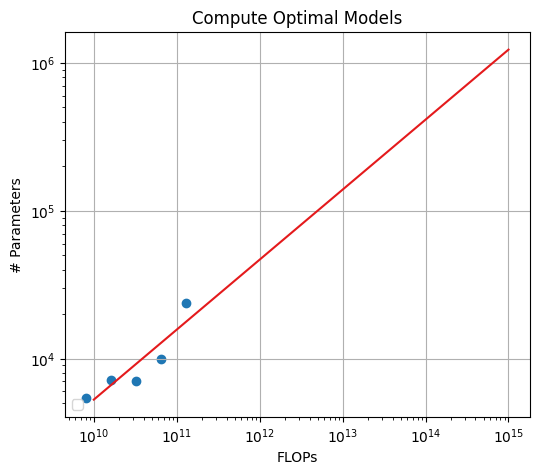

In [39]:
plot_flops_params(target_flops, optimal_params)

## Step 3: Optimal Number of Tokens

Finally, we'll perform a similar analysis to the previous step, only this time determining the optimal number of tokens for a budget of 1e15 flops.

y = 0.48889391749932637x + 0.9944965029346104


/content/drive/MyDrive/NNDL_hw2/hw_utils.py:287: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = "lower left")


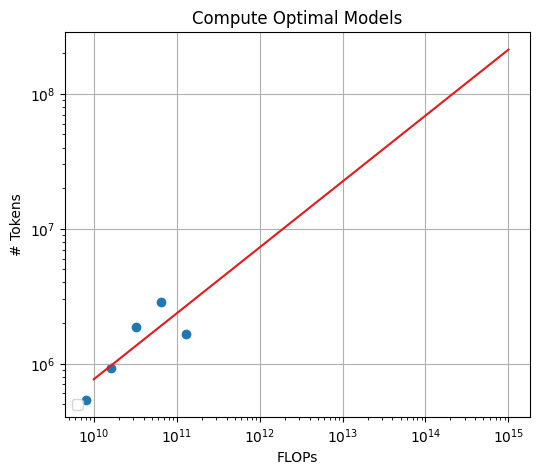

In [40]:
plot_flops_tokens(target_flops, optimal_params, all_results)